# Markov chains from the ground up

This is the first notebook in a five-part series, and it assumes you have
never met a Markov chain before. You need basic Python with numpy, and
probability at the level of "a fair die shows a six one time in six".
Everything else gets built here, one small step at a time.

Why bother? Because a surprising number of real systems boil down to the
same question: something moves between a handful of conditions over time,
and you want to know where it ends up. A loan is current, then late, then
either cured or written off. A market is calm, then stressed, then calm
again. A multi-step AI agent is working, working, working, then finished
or failed. A subscriber is new, then engaged, then wavering, then
gone. The rest of the series works through exactly those examples,
and every one of them runs on the ideas in this notebook:

1. **States and the Markov property**, the assumption that makes
   everything tractable
2. **The transition matrix**, one small table that describes the whole
   system
3. **The long run**, what happens when you let the process keep going

Take your time with this one. The later notebooks move faster because
they stand on it.

## States, and how much memory you need

Watch any system at regular ticks of a clock and write down its condition
at each tick. That condition is called the **state**. The weather today is
sunny or rainy. A customer this month is active, dormant, or churned. A
board game piece is on square 14. The state is a snapshot: everything you
care to record about the system at one moment.

Now the question that defines this whole subject. If I want to predict
the next state, how much of the history do I need?

A bag of colored balls makes the two possible answers concrete. Draw
balls one at a time **without** putting them back, and the probability of
the next color depends on everything drawn so far, because every draw
changes what remains in the bag. Prediction needs the full history. Now
play the same game but **return each ball after drawing it**. The bag is
identical before every draw, so knowing the last draw (or all of them)
tells you nothing extra. The process has no memory.

The **Markov property** is the middle ground that turns out to be the
sweet spot for modeling: the next state may depend on the current state,
but on nothing older. In symbols, for a process $X_0, X_1, X_2, \ldots$:

$$P(X_{n+1} = j \mid X_n = i, \text{everything before } n) = P(X_{n+1} = j \mid X_n = i)$$

Read it as: given where you are now, the path that brought you here is
irrelevant.

Is that literally true of weather, customers, or loans? Almost never. A
loan that has been late three times is usually riskier than one late for
the first time, even if both sit in the same "late" state today. Treating
a system as Markov is a modeling decision, not a law of nature. What the
decision buys you is enormous: the whole future of the process gets
summarized by one small matrix, and questions about years from now become
short linear algebra. The craft is in choosing states rich enough that
the assumption is close to true, and the later notebooks show how far
that craft can take you.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from markov import MarkovChain

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, INK = '#fab219', '#d03b3b', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

## The transition matrix

Once you accept the Markov property, describing the system takes one
table. For states numbered $1$ to $k$, the **transition matrix** $P$ is a
$k \times k$ grid where entry $P[i, j]$ answers: given that the process
is in state $i$ now, what is the probability it is in state $j$ at the
next tick?

Two reading rules that prevent most beginner confusion:

- **Rows are "today", columns are "tomorrow".** Row $i$ is the complete
  menu of what can happen next from state $i$.
- **Every row sums to 1**, because tomorrow the process must be
  somewhere. Columns carry no such rule: a column sums the chances of
  *arriving* in a state from different origins, and those are
  probabilities from different conditional worlds, so nothing forces
  them to add to anything in particular.

Here is the two-state chain we will dissect for most of this notebook.
From A, we stay or leave with equal chance. From B, we stay put 90% of
the time and return to A only 10% of the time. B is the sticky state,
and that stickiness is about to matter a great deal.

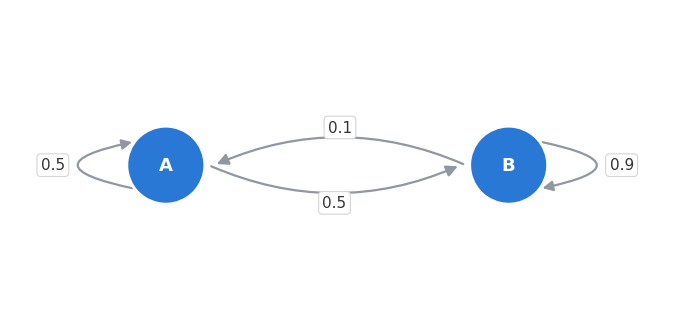

In [2]:
P2 = np.array([[0.5, 0.5],
               [0.1, 0.9]])

mc = MarkovChain(P2, ['A', 'B'])
mc.draw()

The diagram and the matrix carry identical information. Each arrow is one
entry of $P$: the arrows leaving A (0.5 to itself, 0.5 to B) are row one,
the arrows leaving B (0.1 back, 0.9 looping) are row two.

A chain is not just a picture, though. It is a machine you can switch on.
Start it in A, and at every tick draw the next state from the current
row of $P$. Here are 25 ticks of one such run.

In [3]:
rng = np.random.default_rng(11)
labels = ['A', 'B']

path = [0]
for _ in range(24):
    path.append(rng.choice(2, p=P2[path[-1]]))
print(' > '.join(labels[s] for s in path))

A > A > A > B > A > A > B > A > A > B > B > B > B > B > B > B > B > B > B > B > B > B > B > B > B


Even one run shows the character of the chain: short visits to A, long
runs of B. The 0.9 in the corner of the matrix is visible to the naked
eye.

## Two steps ahead, computed by hand first

$P$ answers a one-step question. What about two steps? Say we start in A
and want the probability of being in B two ticks later. There are
exactly two routes:

- **A then A then B**: stay first (0.5), then move (0.5). Probability
  $0.5 \times 0.5 = 0.25$.
- **A then B then B**: move first (0.5), then stay (0.9). Probability
  $0.5 \times 0.9 = 0.45$.

The routes are mutually exclusive, so add them: $0.25 + 0.45 = 0.70$.

Now the observation that unlocks everything. That "multiply along each
route, add across routes" recipe is precisely what matrix multiplication
computes: summing $P[A, k] \cdot P[k, B]$ over every intermediate state
$k$ is the dot product of row A with column B. So the matrix $P \cdot P$
holds the answer to *every* two-step question at once, and in general
$P^n$ holds the $n$-step transition probabilities. One hand calculation
to see why, one line of numpy forever after.

In [4]:
by_hand = 0.5 * 0.5 + 0.5 * 0.9
by_matrix = (P2 @ P2)[0, 1]
print(f"two-step A to B, by hand : {by_hand:.4f}")
print(f"two-step A to B, by P @ P: {by_matrix:.4f}")
assert np.isclose(by_hand, by_matrix)

for n in (1, 2, 5, 20):
    print(f"\nP^{n}:")
    print(np.linalg.matrix_power(P2, n))

two-step A to B, by hand : 0.7000
two-step A to B, by P @ P: 0.7000

P^1:
[[0.5 0.5]
 [0.1 0.9]]

P^2:
[[0.3  0.7 ]
 [0.14 0.86]]

P^5:
[[0.1752 0.8248]
 [0.165  0.835 ]]

P^20:
[[0.1667 0.8333]
 [0.1667 0.8333]]


Look closely at how the powers evolve. At $P^1$ the two rows are nothing
alike, which makes sense: where you are today strongly shapes tomorrow.
By $P^5$ the rows have drifted toward each other. By $P^{20}$ they are
identical to four decimal places: start in A or start in B, twenty ticks
later you are in B with probability about 0.83 either way.

The chain has forgotten its starting point. This is worth watching
happen, not just asserting, so here is the probability of being in B at
every horizon, from both starts.

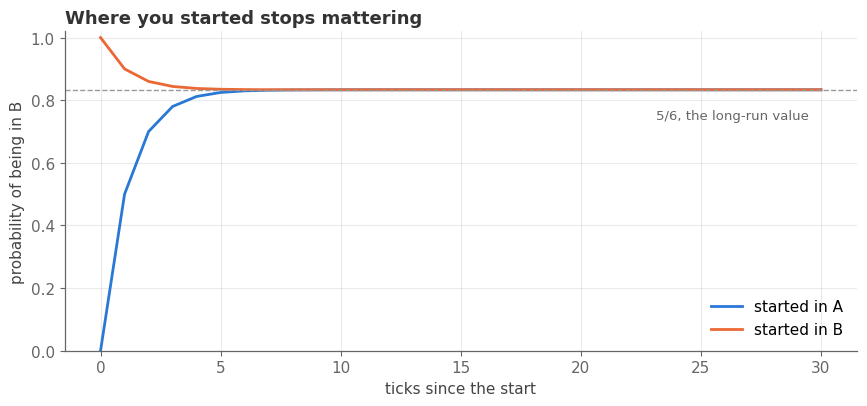

In [5]:
ns = np.arange(0, 31)
from_A = [np.linalg.matrix_power(P2, n)[0, 1] for n in ns]
from_B = [np.linalg.matrix_power(P2, n)[1, 1] for n in ns]

fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.plot(ns, from_A, lw=2, color=BLUE, label='started in A')
ax.plot(ns, from_B, lw=2, color=ORANGE, label='started in B')
ax.axhline(5 / 6, color='#999999', ls='--', lw=1)
ax.annotate('5/6, the long-run value', xy=(30, 5 / 6), xytext=(29.5, 0.74),
            ha='right', fontsize=9.5, color='#666666')
ax.set_xlabel('ticks since the start')
ax.set_ylabel('probability of being in B')
ax.set_ylim(0, 1.02)
ax.set_title('Where you started stops mattering')
ax.legend(loc='lower right')
fig.tight_layout()

Both curves head for the same ceiling, they just approach it from
different sides. That shared limit deserves a name.

## The stationary distribution

The limiting row is called the **stationary distribution**, written
$\pi$: one probability per state, describing where the chain lives in
the long run. It carries two equally useful meanings:

- **Forecast meaning**: far enough in the future, the probability of
  finding the chain in each state is $\pi$, no matter where it began.
- **Time-share meaning**: over one very long run, the *fraction of ticks*
  spent in each state approaches $\pi$.

What pins it down is a balance condition. If today's probabilities
across states are exactly $\pi$, then after one more tick they must
still be $\pi$, otherwise it would hardly deserve the name stationary:

$$\pi P = \pi$$

That equation says $\pi$ is a left eigenvector of $P$ with eigenvalue 1.
If eigenvectors are not a comfortable object for you, do not let the
word block you: we are just asking numpy to solve "which probability
vector does one step of this chain leave unchanged?". Numpy finds
eigenvectors of $M v = \lambda v$ form, so we hand it the transpose of
$P$ to turn our row-vector equation into that shape, then rescale the
answer so it sums to 1 (any multiple of an eigenvector is an eigenvector,
and we want the one that is a probability distribution).

In [6]:
eigenvalues, eigenvectors = np.linalg.eig(P2.T)
k = np.argmin(np.abs(eigenvalues - 1.0))
pi = np.real(eigenvectors[:, k])
pi = pi / pi.sum()

print(f"stationary distribution: A = {pi[0]:.4f}, B = {pi[1]:.4f}")
print(f"one more step, pi @ P  : {pi @ P2}")

stationary distribution: A = 0.1667, B = 0.8333
one more step, pi @ P  : [0.1667 0.8333]


Unchanged by a step, exactly as demanded. For this small chain the exact
answer is $\pi = (1/6, \; 5/6)$: the chain spends one tick in six in A
and five in B. B's stickiness (0.9 on the diagonal) is what earns it the
lion's share.

Before trusting the eigenvector route, let us earn the result a second
way. The time-share meaning of $\pi$ suggests a completely different
computation: run the machine for a very long time and just count. If a
matrix decomposition and a random walk agree on the same number, a bug
would have to infect both, and they share no code at all. Getting an
important number by two unrelated methods is a habit worth stealing; the
rest of this series does it constantly.

In [7]:
rng = np.random.default_rng(7)
state, visits = 0, np.zeros(2)
n_steps = 100_000
for _ in range(n_steps):
    state = rng.choice(2, p=P2[state])
    visits[state] += 1

share = visits / n_steps
print(f"share of ticks, one {n_steps:,}-step walk: A = {share[0]:.4f}, B = {share[1]:.4f}")
print(f"stationary distribution (eigenvector)  : A = {pi[0]:.4f}, B = {pi[1]:.4f}")

share of ticks, one 100,000-step walk: A = 0.1639, B = 0.8361
stationary distribution (eigenvector)  : A = 0.1667, B = 0.8333


The walk lands within about three parts in a thousand of the
eigenvector's answer, which is the amount of luck you should expect in
a hundred thousand random steps. Two computations that share nothing
but the matrix, one number. That is as close to a proof as numerics
gets.

## Scaling up: four states

Nothing about the machinery cared that there were two states. Here is a
four-state chain, deliberately abstract so you watch the structure
rather than a story: A drifts everywhere, B funnels hard into D, C and D
push traffic back toward A. The diagram is already getting crowded at
four states, which is precisely why the matrix, not the picture, is the
working representation.

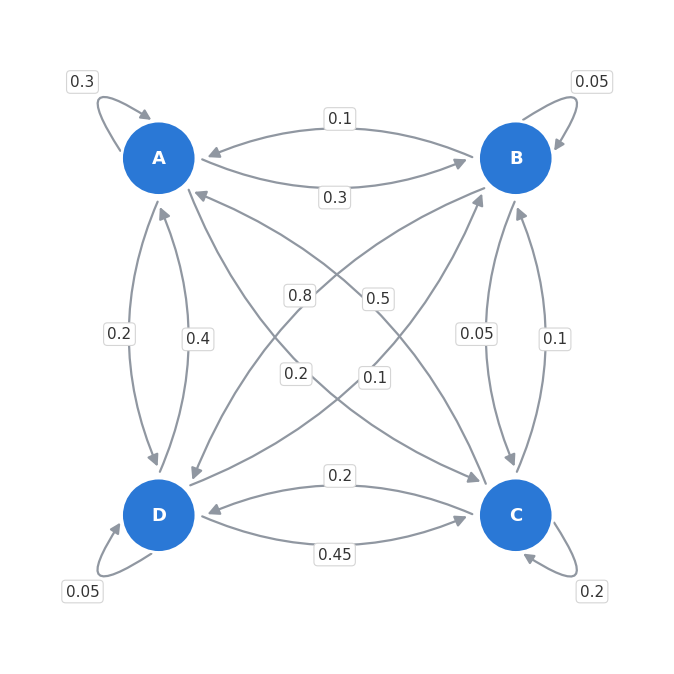

In [8]:
P4 = np.array([[0.3,  0.3,  0.2,  0.2],
               [0.1,  0.05, 0.05, 0.8],
               [0.5,  0.1,  0.2,  0.2],
               [0.4,  0.1,  0.45, 0.05]])

mc4 = MarkovChain(P4, ['A', 'B', 'C', 'D'])
mc4.draw()

In [9]:
eigenvalues, eigenvectors = np.linalg.eig(P4.T)
k = np.argmin(np.abs(eigenvalues - 1.0))
pi4 = np.real(eigenvectors[:, k])
pi4 = pi4 / pi4.sum()

print("long-run share of time in each state:")
for label, share in zip(['A', 'B', 'C', 'D'], pi4):
    print(f"  {label}: {share:.4f}")

print(f"\nrow of P^50, any start: {np.linalg.matrix_power(P4, 50)[0]}")

long-run share of time in each state:
  A: 0.3418
  B: 0.1603
  C: 0.2403
  D: 0.2576

row of P^50, any start: [0.3418 0.1603 0.2403 0.2576]


The eigenvector and the 50th matrix power tell the same story, which by
now should feel inevitable rather than lucky.

## When is the long run guaranteed?

Quietly, everything above leaned on two properties of these particular
chains, and honesty requires naming them.

First, every state can eventually reach every other state (the chain is
**irreducible**). Break that, say two clusters of states with no arrows
between them, and there is no single long-run answer: where you end up
depends forever on which island you started on.

Second, the chain does not move in forced cycles (it is **aperiodic**).
A chain that must alternate A, B, A, B never settles into a limit; at
even ticks it is one place, at odd ticks the other. Any self-loop, like
the diagonals in our matrices, is enough to break such rhythms.

A chain with both properties is called **regular**, and for regular
chains the guarantee is complete: a unique stationary distribution
exists, the rows of $P^n$ all converge to it, and the starting state
washes out. Both chains above qualify, which is why the experiments
behaved so cleanly.

There is one more way to violate the setup, and it is the important one:
a state you can enter but never leave. Once a loan is written off, it
stays written off. No amount of waiting produces a stationary
distribution spread across the states, because all the probability
eventually piles into the exits. For those chains, called **absorbing**,
the interesting questions change from "where does the process spend its
time" to "which exit does it take, and how long until it gets there".
That is notebook 02, and it is where this material starts earning money.

## Vocabulary, in plain words

| Term | Plain meaning |
|------|---------------|
| state | the system's condition at one tick, one item from a fixed menu |
| Markov property | the next state depends only on the current one, not the path here |
| transition matrix $P$ | row $i$, column $j$: probability of going from $i$ to $j$ in one tick |
| $P^n$ | the same table for $n$ ticks ahead |
| stationary distribution $\pi$ | the long-run share of time in each state; solves $\pi P = \pi$ |
| irreducible | every state can eventually reach every other |
| aperiodic | no forced cycles; self-loops are an easy sufficient condition |
| absorbing state | a state you can enter but never leave |

## Takeaways

1. A Markov chain is a memoryless walk over a finite menu of states,
   fully described by one row-stochastic matrix.
2. Matrix multiplication is not a trick; it is the "multiply along
   routes, add across routes" rule you would use by hand, applied to
   every route at once. $P^n$ answers every $n$-step question.
3. Regular chains forget their starting point, and the place they settle,
   the stationary distribution, can be computed as an eigenvector and
   verified by brute-force counting. Get important numbers twice.
4. The moment a chain contains a state with no exit, this notebook's
   question dissolves and a better one takes its place. That is where we
   go next.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*